In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


Global variables

In [12]:
dimension = 256 #size of matrix

Object

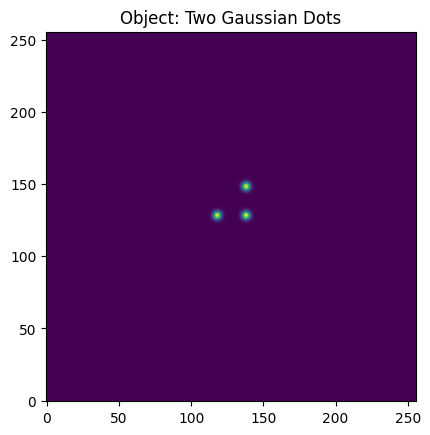

In [23]:
# Object matrix
Obj = np.zeros((dimension, dimension))

centre_x = dimension // 2
centre_y = dimension // 2
seperation = 20   

# set dot position
Obj[centre_y, centre_x - seperation//2] = 1
Obj[centre_y, centre_x + seperation//2] = 1
Obj[centre_y + seperation , centre_x + seperation//2] = 1

# Convert to Gaussian dots 
Obj = gaussian_filter(Obj, sigma=2)

plt.imshow(Obj, origin='lower')
plt.title("Object: Two Gaussian Dots")
plt.show()

Random Speckle Pattern

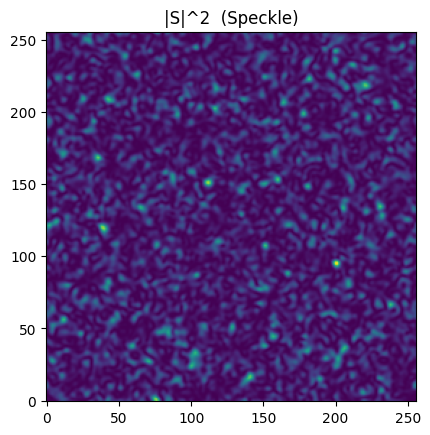

In [24]:
# Coordinate grid, 0 centred 
Y, X = np.indices((dimension, dimension))
X = X - dimension//2
Y = Y - dimension//2

#gaussian envelope
sigma_env = 20 #standard deviation 
gaussian_env = np.exp(-(X**2 + Y**2) / (2 * sigma_env**2))

# Random complex matrix
rand_complex = (
    np.random.uniform(-1, 1, (dimension, dimension)) + 1j * np.random.uniform(-1, 1, (dimension, dimension))
)

# field at barrier
field = rand_complex * gaussian_env

# speckle pattern - random
speckle_rand = np.fft.fftshift(np.fft.fft2(field)) # fast fourier transform, shift to centre
intensity_rand = np.abs(speckle_rand)**2

plt.imshow(intensity_rand, origin='lower')
plt.title("|S|^2  (Speckle)")
plt.show()

Image

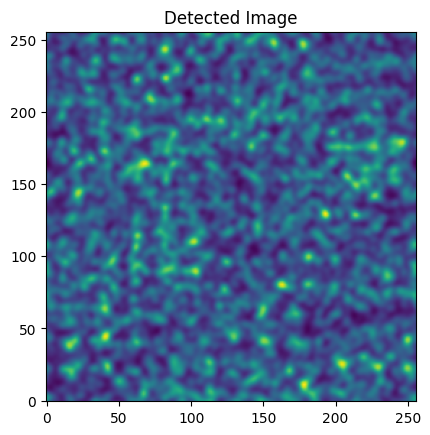

In [25]:
# Convolution of speckle and object
image = np.fft.ifft2(
        np.fft.fft2(Obj) * np.fft.fft2(intensity_rand)
    )

image = np.real(image)

plt.imshow(image, origin='lower')
plt.title("Detected Image")
plt.show()

Autocorrelation

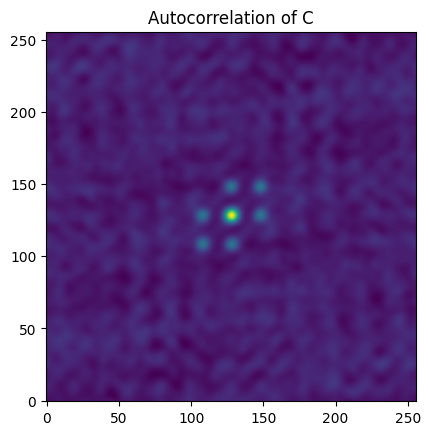

In [26]:
# Remove background 
image_clean = image - np.mean(image)

# Autocorrelation
image_auto = np.fft.ifft2(np.abs(np.fft.fft2(image_clean))**2)

# Take real part 
image_auto = np.real(image_auto)

# centre the autocorrelation
image_auto = np.fft.fftshift(image_auto)

plt.imshow(image_auto, origin='lower')   
plt.title("Autocorrelation of C")
plt.show()